# Небольшая демонстрация эмбеддингов, кластеризация и Phi-3

Этот notebook показывает учебный сценарий для DataSphere: загрузить небольшой датасет отзывов, построить эмбеддинги текстов, сгруппировать тексты по смысловой близости и запустить небольшую генеративную модель семейства Microsoft Phi.

Для блока с эмбеддингами обычно достаточно CPU-конфигурации. Для `microsoft/Phi-3-mini-4k-instruct` может потребоваться GPU-конфигурация или машина с достаточным объемом памяти. 

Для начала установим необходимые библиотеки. Чтобы не нарушить работу библиотек с поддержкой GPU, оставим текущие версии библиотеки `torch` без изменений, указав текущую версию в списке ограничений на установку.

In [4]:
%pip freeze | grep torch

torch @ https://download.pytorch.org/whl/cu118/torch-2.0.1%2Bcu118-cp310-cp310-linux_x86_64.whl#sha256=a7a49d459bf4862f64f7bc1a68beccf8881c2fa9f3e0569608e16ba6f85ebf7b
torchaudio @ https://download.pytorch.org/whl/cu118/torchaudio-2.0.2%2Bcu118-cp310-cp310-linux_x86_64.whl#sha256=26692645ea061a005c57ec581a2d0425210ac6ba9f923edf11cc9b0ef3a111e9
torchdata==0.6.1
torchsummary==1.5.1
torchtext==0.15.2
torchvision @ https://download.pytorch.org/whl/cu118/torchvision-0.15.2%2Bcu118-cp310-cp310-linux_x86_64.whl#sha256=19ca4ab5d6179bbe53cff79df1a855ee6533c2861ddc7389f68349d8b9f8302a


In [2]:
%pip install torch==2.0.1 sentence-transformers transformers==4.49.0 accelerate

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [ ]:
%pip install -q datasets sentence-transformers scikit-learn matplotlib pandas transformers accelerate torch

## Подготавливаем данные

Для студентов мы предполагаем, что необходимые подготовленные данные будут лежать в файловом хранилище, которое будет доступно им в `filestore/data` (полный путь к директории: `/home/jupyter/filestore/data/home/jupyter/filestore/data`). В этой предварительной ячейке мы скачаем исходные отзывы, подготовим их в удобном для использования студентами формате, и загрузим в директорию `data`. В дальнейшем эти ячейки можно удалить, чтобы студенты сразу пользовались готовым датасетом. 

Наш датасет - это отзывы о разных вокзалах Москвы. Скачаем все отзывы в виде архива из первоначального местоположения:

In [2]:
!wget https://storage.yandexcloud.net/mypub/data/rail_reviews.zip

--2026-08-29 20:52:53--  https://storage.yandexcloud.net/mypub/data/rail_reviews.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 390394 (381K) [application/x-zip-compressed]
Saving to: ‘rail_reviews.zip’

     0K .......... .......... .......... .......... .......... 13% 2.08M 0s
    50K .......... .......... .......... .......... .......... 26% 1.32M 0s
   100K .......... .......... .......... .......... .......... 39% 1.42M 0s
   150K .......... .......... .......... .......... .......... 52% 1.31M 0s
   200K .......... .......... .......... .......... .......... 65% 1.37M 0s
   250K .......... .......... .......... .......... .......... 78% 1.34M 0s
   300K .......... .......... .......... .......... .......... 91% 1.55M 0s
   350K .......... .......... .......... .                 

Теперь прочитаем все отзывы и преобразуем их в датасет Pandas:

In [4]:
import pandas as pd
import zipfile
import json

res = []
with zipfile.ZipFile('rail_reviews.zip','r') as fzip:
    for fn in fzip.infolist():
          content = fzip.read(fn.filename)
          j = json.loads(content.decode('utf-8'))
          for x in j:
            x['station'] = fn.filename.split('_')[1]
          res.extend(j)
    
df = pd.DataFrame(res)
df

,id,dislike,like,review_text,author,review_rating,datetime,station
0,1251,1,10,"Очень красивое место, вежливый персонал.\nЕзди...",Александра Подгайская,5,2024-01-12T16:53:33.611Z,Belorussky
1,1252,0,5,"Расположен очень удобное, строятся новые пути ...",Пользователь Э.,5,2023-11-10T21:33:56.176Z,Belorussky
2,1253,2,7,Очень уютный и удобный вокзал. Мне он очень нр...,Н И,5,2023-08-25T14:27:29.327Z,Belorussky
3,1254,1,5,"Красивое здание , очень удобно расположено в т...",Liliya Zugrova,5,2023-11-27T11:50:16.388Z,Belorussky
4,1255,2,7,С появление новых веток и маршрутов все стало ...,Татьяна Цымлова,5,2023-11-25T06:43:16.558Z,Belorussky
...,...,...,...,...,...,...,...,...
2264,2266,0,1,"Отличный вокзал. Новый, современный, прям из в...",Анна Елагина,5,2024-02-02T04:55:15.074Z,Vostochny
2265,2267,1,0,Бывал недавно там )) очень вкусная кухня \nКла...,Дмитрий,5,2023-11-12T14:21:47.541Z,Vostochny
2266,2268,0,0,Отличный и красивый вокзал. Чистые туалеты и б...,Валентина Архимановна,5,2024-01-31T10:53:36.364Z,Vostochny
2267,2269,3,10,"Это не вокзал , а скорее узловая станция или п...",Владислав Баранов,2,2023-12-06T12:03:14.107Z,Vostochny


Запишем получившийся файл в файловое хранилище для всех студентов:

In [14]:
df.to_csv('/home/jupyter/filestore/data/rail_reviews.csv',index=False)

В заключении удалим скачанный zip-файл:

In [15]:
!rm rail_reviews.zip

## Открываем датасет

С этого места начинается работа студента. Предполагается, что он открыл проект с подключенным файловым хранилищем, в котором уже размещён датасет отзывов. Начинаем с того, что читаем и показываем датасет:

In [2]:
import pandas as pd

df = pd.read_csv('/home/jupyter/filestore/data/rail_reviews.csv')
df

,id,dislike,like,review_text,author,review_rating,datetime,station
0,1251,1,10,"Очень красивое место, вежливый персонал.\nЕзди...",Александра Подгайская,5,2024-01-12T16:53:33.611Z,Belorussky
1,1252,0,5,"Расположен очень удобное, строятся новые пути ...",Пользователь Э.,5,2023-11-10T21:33:56.176Z,Belorussky
2,1253,2,7,Очень уютный и удобный вокзал. Мне он очень нр...,Н И,5,2023-08-25T14:27:29.327Z,Belorussky
3,1254,1,5,"Красивое здание , очень удобно расположено в т...",Liliya Zugrova,5,2023-11-27T11:50:16.388Z,Belorussky
4,1255,2,7,С появление новых веток и маршрутов все стало ...,Татьяна Цымлова,5,2023-11-25T06:43:16.558Z,Belorussky
...,...,...,...,...,...,...,...,...
2264,2266,0,1,"Отличный вокзал. Новый, современный, прям из в...",Анна Елагина,5,2024-02-02T04:55:15.074Z,Vostochny
2265,2267,1,0,Бывал недавно там )) очень вкусная кухня \nКла...,Дмитрий,5,2023-11-12T14:21:47.541Z,Vostochny
2266,2268,0,0,Отличный и красивый вокзал. Чистые туалеты и б...,Валентина Архимановна,5,2024-01-31T10:53:36.364Z,Vostochny
2267,2269,3,10,"Это не вокзал , а скорее узловая станция или п...",Владислав Баранов,2,2023-12-06T12:03:14.107Z,Vostochny


## Строим эмбеддинги

Эмбеддинг переводит текст в числовой вектор. Близкие по смыслу тексты обычно получают близкие векторы. В примере используется мультиязычная модель `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`, которая подходит для русскоязычных учебных демонстраций и не требует API-ключа.

In [1]:
from sentence_transformers import SentenceTransformer

embedding_model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(embedding_model_name)

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:106: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-08-29 23:07:58.525564: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-29 23:08:00.519336: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-29 23:08:05.403085: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/usr/local/lib/python3.10/dist

Теперь собственно запускаем вычисления эмбеддингов для всех текстов отзывов:

In [4]:
embeddings = embedder.encode(
    df['review_text'].values,
    batch_size=32,
    normalize_embeddings=True,
    show_progress_bar=True,
)

embeddings.shape

Batches: 100%|██████████| 71/71 [00:48<00:00,  1.47it/s]


(2269, 384)

Теперь попробуем визуализировать эмбеддинги в 2D. Для этого можно использовать преобразование PCA. В качестве цвета для визуализации будем использовать поле **review_rating** из исходной таблицы, чтобы понять, есть ли какая-то корреляция рейтинга с отзывом.

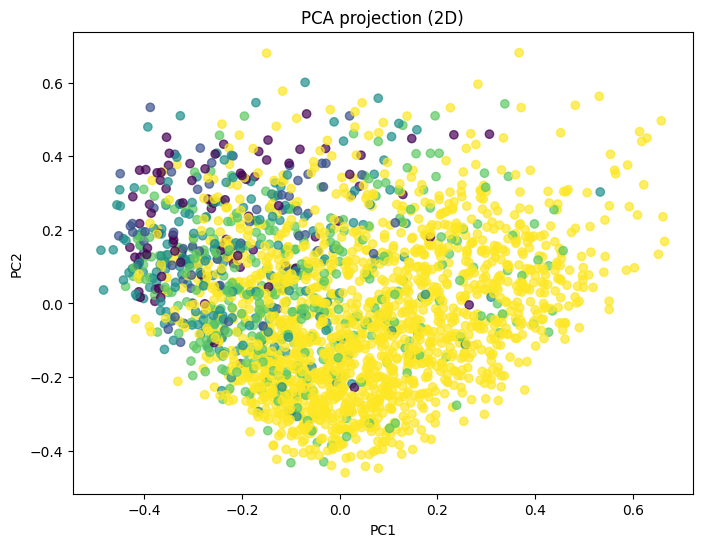

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], alpha=0.7, c=df['review_rating'])
plt.title("PCA projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Можно попробовать более сильный алгоритм t-SNE:

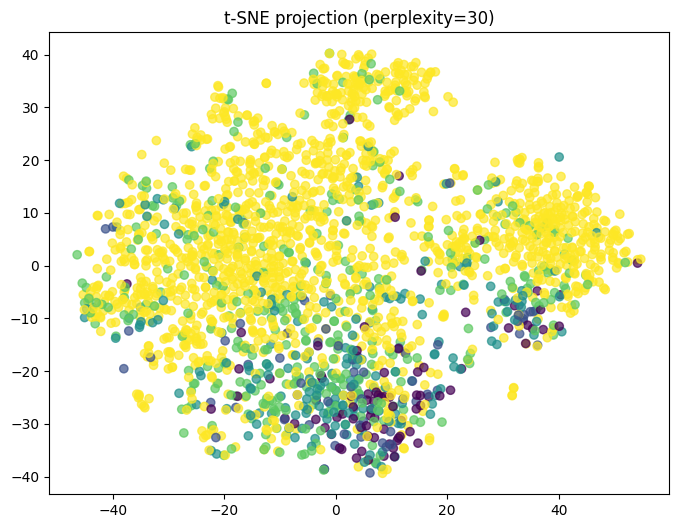

In [8]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_tsne = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], alpha=0.7, c=df['review_rating'])
plt.title("t‑SNE projection (perplexity=30)")
plt.show()

## Кластеризуем тексты

Кластеризация помогает увидеть группы похожих текстов без ручной разметки. Для определения количества кластеров используют **метод локтя** - строят график инерции в зависимости от количества кластеров.

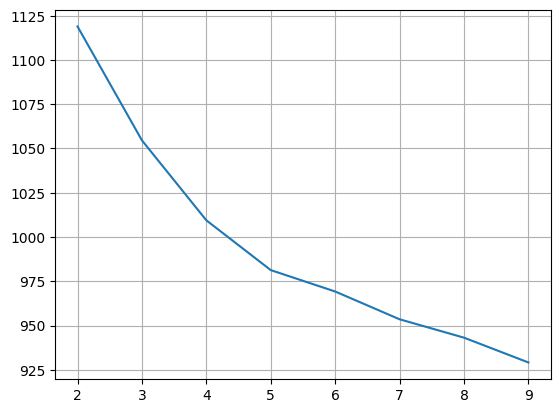

In [19]:
from sklearn.cluster import KMeans

res = []
for n in range(2,10):
    kmeans = KMeans(n_clusters=n, random_state=42, n_init="auto").fit(embeddings)
    res.append(kmeans.inertia_)

plt.plot(range(2,10),res)
plt.grid()
plt.show()

Число кластеров 5 выглядит разумным:

In [21]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(embeddings)

df["cluster"] = clusters
df

,id,dislike,like,review_text,author,review_rating,datetime,station,cluster
0,1251,1,10,"Очень красивое место, вежливый персонал.\nЕзди...",Александра Подгайская,5,2024-01-12T16:53:33.611Z,Belorussky,1
1,1252,0,5,"Расположен очень удобное, строятся новые пути ...",Пользователь Э.,5,2023-11-10T21:33:56.176Z,Belorussky,0
2,1253,2,7,Очень уютный и удобный вокзал. Мне он очень нр...,Н И,5,2023-08-25T14:27:29.327Z,Belorussky,0
3,1254,1,5,"Красивое здание , очень удобно расположено в т...",Liliya Zugrova,5,2023-11-27T11:50:16.388Z,Belorussky,1
4,1255,2,7,С появление новых веток и маршрутов все стало ...,Татьяна Цымлова,5,2023-11-25T06:43:16.558Z,Belorussky,4
...,...,...,...,...,...,...,...,...,...
2264,2266,0,1,"Отличный вокзал. Новый, современный, прям из в...",Анна Елагина,5,2024-02-02T04:55:15.074Z,Vostochny,0
2265,2267,1,0,Бывал недавно там )) очень вкусная кухня \nКла...,Дмитрий,5,2023-11-12T14:21:47.541Z,Vostochny,2
2266,2268,0,0,Отличный и красивый вокзал. Чистые туалеты и б...,Валентина Архимановна,5,2024-01-31T10:53:36.364Z,Vostochny,0
2267,2269,3,10,"Это не вокзал , а скорее узловая станция или п...",Владислав Баранов,2,2023-12-06T12:03:14.107Z,Vostochny,4


Посмотрим на примеры текстов внутри кластеров:

In [23]:
for cluster_id in sorted(df["cluster"].unique()):
    print(f"\n=== Cluster {cluster_id} ===")
    examples = df[df["cluster"] == cluster_id].head(5)
    for _, row in examples.iterrows():
        print(f"+ {row['review_text']}")


=== Cluster 0 ===
+ Расположен очень удобное, строятся новые пути и оптимизируются пересадочные узлы. В здании вокзала есть бургер Кинг, несколько бюджетных кафешек и ларьков. Много валидаторов, а пересадка между диаметров так и вовсе без них - для удобства. Туалеты только мрак, но в БК нормально :)
+ Очень уютный и удобный вокзал. Мне он очень нравится! В шаговой доступности метро, удобная высадка и посадка в такси. Не нужно бегать по этажам: проходишь досмотр, небольшой вестибюль- и вот уже платформы. Современный навес надёжно защищает перрон от дождя и снега. На платформе недалеко от табло есть туалеты. Электронное табло расположено удобно. Ну и кроме удобств здесь красиво! Отдельного внимания безусловно заслуживает памятник "Прощание славянки". Он такой проникновенный, трогательный, что невольно подступают слёзы... Если обойдёте скульптурную группу по кругу, то вы прочтёте все слова этого марша.
+ Очень красивый вокзал, с красивой архитектурой, с красивым видом на город, удобное м

## Визуализируем кластеры

Мы можем теперь визуализировать кластеры в PCA-проекциях:

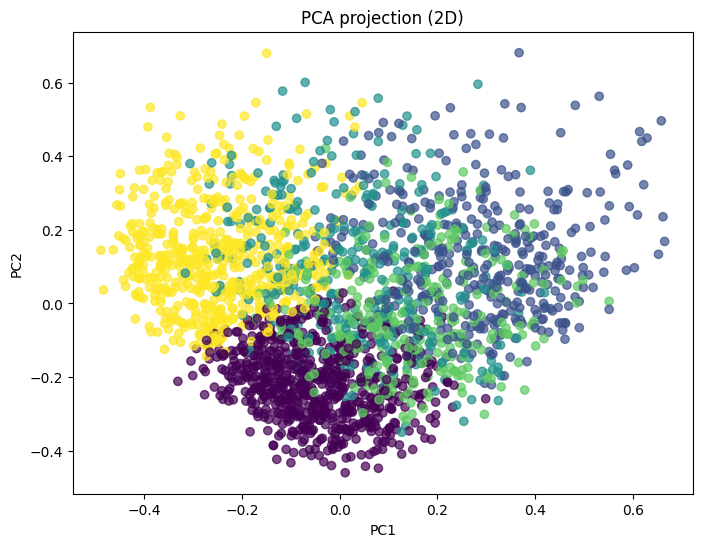

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], alpha=0.7, c=df['cluster'])
plt.title("PCA projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Запускаем генеративную модель Phi-3

Предположим теперь, что мы хотим использовать языковую модель для суммаризации всех отзывов в каждом из кластеров, или для определения тональности текста. У нас есть выбор:

* Использовать облачную модель AI Studio (для этого понадобится `api_key` и `folder_id`). Это наиболее простой вариант
* Запустить какую-то модель с открытыми весами из HuggingFace. Для этого понадобится GPU.

Для начала сохраним датасет с результатами кластеризации в каталог проекта:

In [25]:
df.to_csv('reviews_clustered.csv',index=False)

Теперь мы можем отключить виртуальную машину и при запуска следующей ячейки выбрать конфигурацию с GPU (например, g1.1 с Tesla V100).

В качестве локальной модели будем использовать `microsoft/Phi-3-mini-4k-instruct`, поскольку она достаточно легковесная. Код для запуска модели возьмём [с её странички на HuggingFace](microsoft/Phi-3-mini-4k-instruct).

In [1]:
import torch
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="microsoft/Phi-3-mini-4k-instruct",
    device_map="auto",
    torch_dtype="auto",
    trust_remote_code=True,
)

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:106: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-08-29 23:39:17.186891: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-29 23:39:18.568168: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/usr/local/lib/python3.10/dist-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://git

In [9]:
messages = [
    {"role": "system", "content": "Ты учебный ассистент. Отвечай кратко и проверяй факты."},
    {"role": "user", "content": "Объясни студенту, зачем нужны эмбеддинги текстов и кластеризация."},
]

result = generator(messages, do_sample=True, use_cache=False, max_length=256, return_full_text=False)
print(result[0]["generated_text"])

 Эмбеддинги текстов и кластеризация используются для оптимизации процесса понимания и работы с текстовым данными через анализ их смысла. Это помогает избегать утёсности и подготавливает тексты для обеспечения эффективной интеграции в различные приложения и системы, такие как рекомендации товаров, социальные сети и социальные проекты.

1. Эмбеддинги для текста: Эмбеддинги — это числовые векторы, которые представляют собой сокращённый отбор признаков текстов, оптимизированный для быстродействия в вычислительных приложениях. Они эффективно используются для различных задач обра


> **Если генеративная модель не запускается**: Если Phi-3 не помещается в выбранную конфигурацию, остановите вычисления и выберите более мощную GPU-конфигурацию или более компактную модель.

Попробуем с помощью GPT извлечь основные ключевые слова и темы из каждого из кластеров:


In [11]:
import pandas as pd
df = pd.read_csv('reviews_clustered.csv')

In [15]:
def gpt(system_prompt, prompt, max_new_tokens=128):
    messages = [
        {"role": "system", "content": system_prompt },
        {"role": "user", "content": prompt },
    ]

    result = generator(
        messages, do_sample=True, 
        use_cache=False, max_new_tokens=max_new_tokens, 
        return_full_text=False)
    return result[0]["generated_text"]

system_prompt = """
Ты - редактор текстов. Твоя задача - выделить основные темы из текста 
и ключевые слова. Напиши ответ через запятую.
""".strip()

for cluster_id in sorted(df["cluster"].unique()):
    print(f"\n=== Cluster {cluster_id} ===")
    examples = df[df["cluster"] == cluster_id].head(5)
    examples = [ row['review_text'] for _, row in examples.iterrows() ]
    res = gpt(system_prompt, '\n'.join(examples))
    print(res)


=== Cluster 0 ===
 основные темы - архитектура и красота, удобство и способы перемещения, историческое значение, современные услуги и адаптации, красота и атмосферы вокзала, приятно спасающие потери, уникальная культурная историю, атмосферы вокзала, мощен прием, быстрое пересечение, достопримечательности, достопримечательности вокзала, архитектурные изменения, современ

=== Cluster 1 ===
 plazza, всевозможные архитектурные стили, прохождение энергетического вектора, гостиница, деда Мороза поезда, вагоны для машинок, ресторан, монетки, поездовок для детей и молодежи, очки, хороший выбор ресторанов.

=== Cluster 2 ===
 Удобство, просторность, движение, такси, достопримечательности, скидки, работу, персонал, архитектура, парковка, магазин, сурфметал, лотереи, воспользоваться залом, уборку, ножки, принимать, аппетит, корм, устойчивость, прожитость, безопасность, хорошая атмосфера, невнимательные сторонники, красота, приятность

=== Cluster 3 ===
 Красивое историческое здание, опрыскивчивы

Вы можете видеть, что несмотря на использование GPU для вычислений, и достаточно легковесной модели, обработка текстов занимает существенное время, а качество ответов оставляет желать лучшего. Именно поэтому рекомендуется по возможности использовать языковые модели из AI Studio, поскольку в этом случае Yandex Cloud берёт на себя все вопросы с производительностью.

## Обучим модель для предсказания рейтинга

В некоторых случаях нам хочется иметь возможность предсказывать такие параметры, как рейтинг отзыва, количество лайков или дислайков. Наш датасет очень небольшой, поэтому поэтому используем эмбеддинги:

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model_st = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
embeddings = model_st.encode(df['review_text'].tolist(), show_progress_bar=True)

# Целевая переменная - review_rating (от 1 до 5)
y = df['review_rating'].values - 1  # сдвиг на 0..4 для категориальной кросс-энтропии

# Разбиение (стратифицированное)
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, y, test_size=0.2, random_state=42, stratify=y
)

# Нормализация (очень помогает нейросетям)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 04807436-54cc-45b4-8d7c-c55eefb5ba85)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].
Batches: 100%|██████████| 71/71 [00:01<00:00, 40.00it/s]


Поверх эмбеддингов будем использовать простую полносвязную нейросеть. Для разнообразия, применим фреймвор TensorFlow, который также по умолчанию доступен в Datasphere:

In [21]:
model = keras.Sequential([
    layers.Input(shape=(384,)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),      # стабилизирует обучение
    layers.Dropout(0.3),              # регуляризация
    layers.Dense(5, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 64)                24640     
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 5)                 325       
                                                                 
Total params: 25,221
Trainable params: 25,093
Non-trainable params: 128
_________________________________________________________________


Запускаем обучение, при этом используем раннюю остановку в том случае, если точность на тестовой выборке начинает расти:

In [22]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test,y_test),
    epochs=100,
    callbacks=[early_stop],
    batch_size=32)

Epoch 1/100
57/57 [==============================] - 2s 9ms/step - loss: 1.7057 - accuracy: 0.4165 - val_loss: 1.6432 - val_accuracy: 0.4229
Epoch 2/100
57/57 [==============================] - 0s 5ms/step - loss: 1.1928 - accuracy: 0.6132 - val_loss: 1.2619 - val_accuracy: 0.5419
Epoch 3/100
57/57 [==============================] - 0s 5ms/step - loss: 0.9814 - accuracy: 0.6854 - val_loss: 1.0391 - val_accuracy: 0.6476
Epoch 4/100
57/57 [==============================] - 0s 5ms/step - loss: 0.8293 - accuracy: 0.7163 - val_loss: 0.9092 - val_accuracy: 0.6916
Epoch 5/100
57/57 [==============================] - 0s 5ms/step - loss: 0.7419 - accuracy: 0.7372 - val_loss: 0.8470 - val_accuracy: 0.7115
Epoch 6/100
57/57 [==============================] - 0s 5ms/step - loss: 0.6658 - accuracy: 0.7725 - val_loss: 0.8525 - val_accuracy: 0.7048
Epoch 7/100
57/57 [==============================] - 0s 5ms/step - loss: 0.6141 - accuracy: 0.7736 - val_loss: 0.8388 - val_accuracy: 0.7093
Epoch 8/100
5

Посчитаем итоговую достигнутую точность и построим матрицу ошибок:

Test Accuracy: 0.7313
15/15 [==============================] - 0s 2ms/step


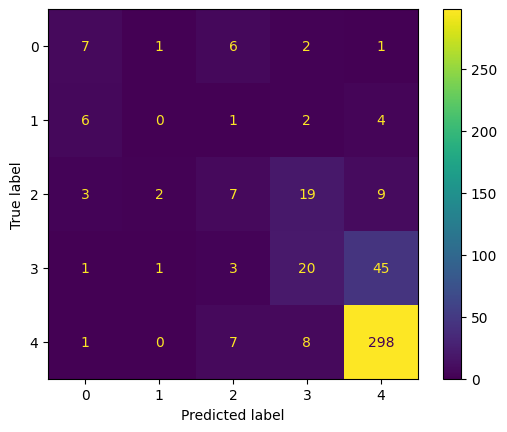

In [27]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()


Мы видим, что качество предсказания не очень хорошее. В первую очередь это связано с тем, что отзывы не всегда бывают однозначно плохими или хорошими, и возможна путаница. Также качество и количество данных не очень высоки, и наблюдается очень существенный сдвиг в сторону 5-балльных отзывов.

## Завершение занятия

Перед завершением занятия сохраните notebook и остановите вычисления DataSphere. По умолчанию виртуальная машина Datasphere останавливается через несклько часов простоя, но при использовании GPU для экономии ресурсов лучше выключать её вручную. 